<a href="https://colab.research.google.com/github/SalmiFatimaZahra/Gestion-des-salaires-des-employ-s-dans-une-entreprise-/blob/main/CompluterVisionOper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

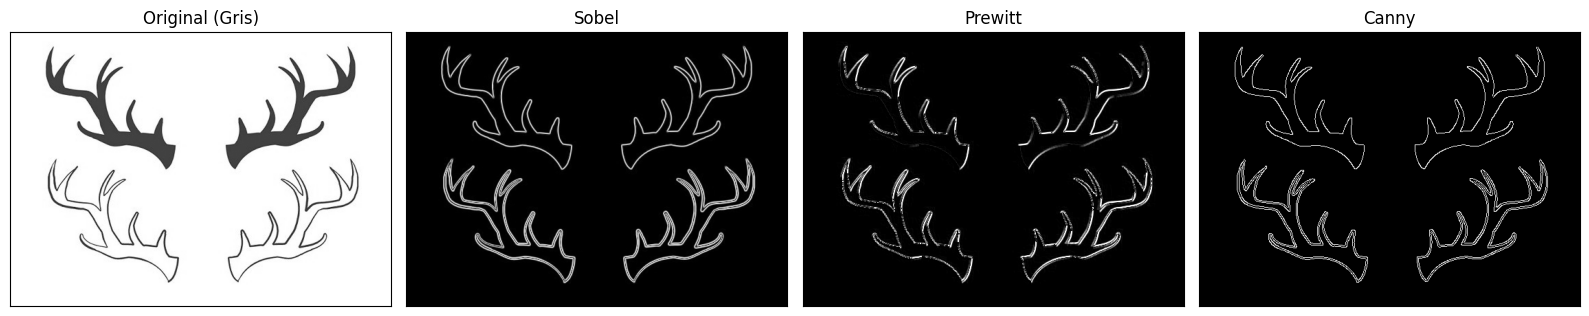

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Charger l'image en niveaux de gris
img = cv2.imread('img.png', cv2.IMREAD_GRAYSCALE)

# # Appliquer un léger flou pour réduire le bruit avant la détection
# img_blur = cv2.GaussianBlur(img, (3, 3), 0)

# --- SOBEL ---
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)

# --- PREWITT ---
kernelx = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
kernely = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
prewittx = cv2.filter2D(img, -1, kernelx)
prewitty = cv2.filter2D(img, -1, kernely)
prewitt_combined = prewittx + prewitty

# --- CANNY ---
# Les seuils 100 et 200 sont à ajuster selon la netteté voulue
canny = cv2.Canny(img, 100, 200)

# Visualisation
titles = ['Original (Gris)', 'Sobel', 'Prewitt', 'Canny']
images = [img, sobel_combined, prewitt_combined, canny]

plt.figure(figsize=(16, 8))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

chatgpt

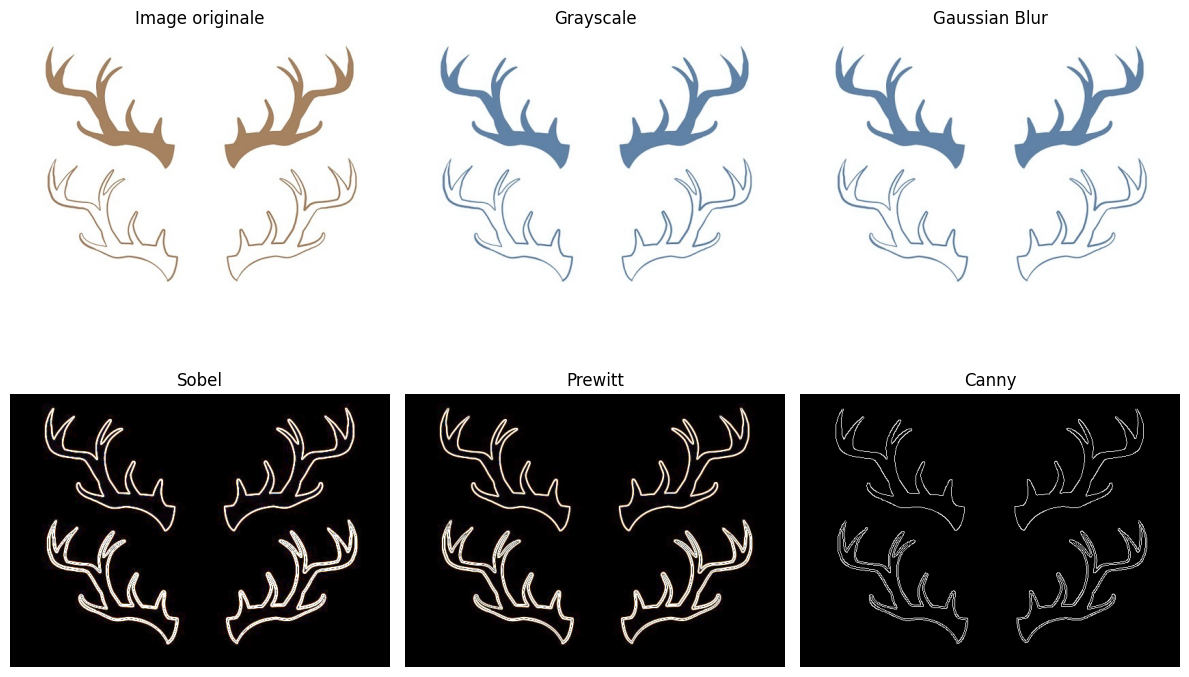

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Lire l'image
img = cv2.imread("img.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# # Niveau de gris
# gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# # Flou gaussien
# blur = cv2.GaussianBlur(gray, (5, 5), 1)

# ----------------------
# Sobel
# ----------------------
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = cv2.convertScaleAbs(sobel_mag)

# ----------------------
# Prewitt
# ----------------------
kernelx = np.array([[-1, 0, 1],
                    [-1, 0, 1],
                    [-1, 0, 1]], dtype=np.float32)

kernely = np.array([[-1, -1, -1],
                    [ 0,  0,  0],
                    [ 1,  1,  1]], dtype=np.float32)

prewitt_x = cv2.filter2D(img, cv2.CV_32F, kernelx)
prewitt_y = cv2.filter2D(img, cv2.CV_32F, kernely)
prewitt_mag = np.sqrt(prewitt_x**2 + prewitt_y**2)
prewitt_mag = cv2.convertScaleAbs(prewitt_mag)

# ----------------------
# Canny
# ----------------------
canny = cv2.Canny(img, 50, 150)

# ----------------------
# Affichage
# ----------------------
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img_rgb)
plt.title("Image originale")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(img, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(img, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(sobel_mag, cmap="gray")
plt.title("Sobel")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(prewitt_mag, cmap="gray")
plt.title("Prewitt")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(canny, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.tight_layout()
plt.show()

TP

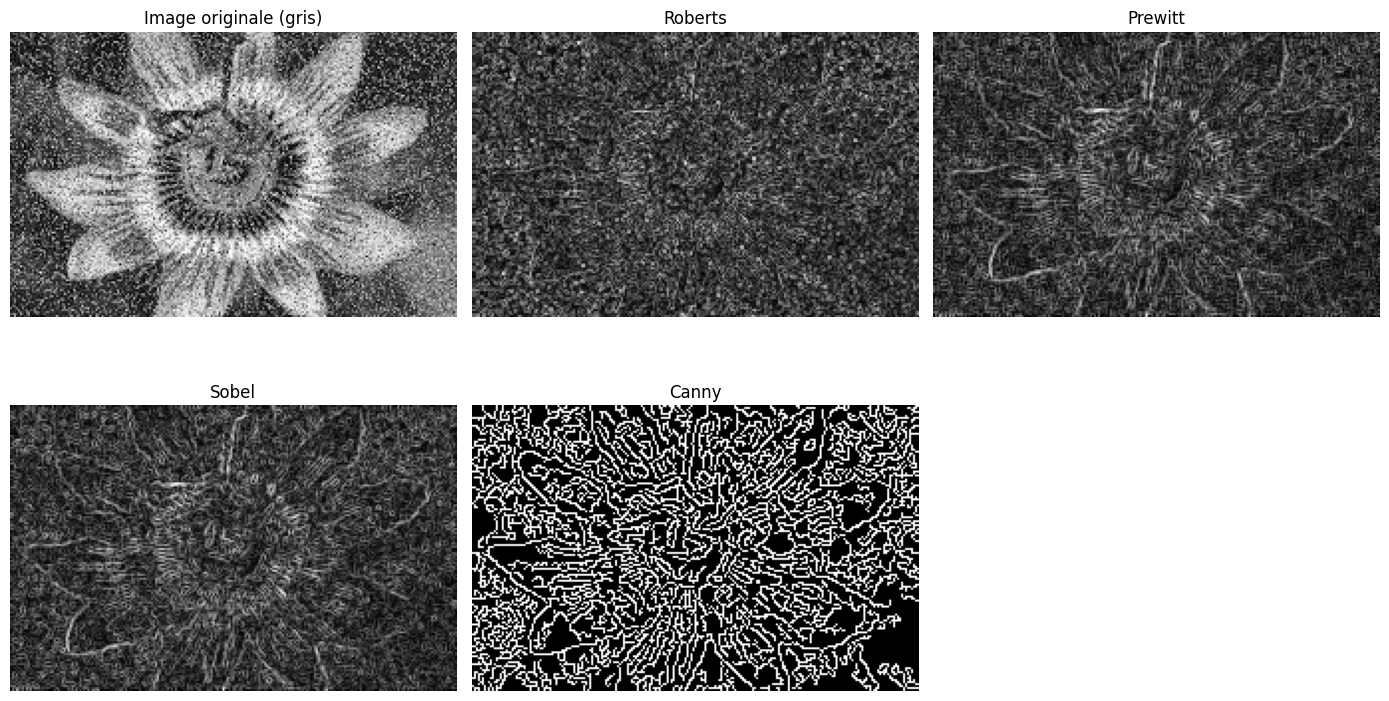

[OK] sauvegardé : resultats_tp3/original_gray.png
[OK] sauvegardé : resultats_tp3/roberts.png
[OK] sauvegardé : resultats_tp3/prewitt.png
[OK] sauvegardé : resultats_tp3/sobel.png
[OK] sauvegardé : resultats_tp3/canny.png
[OK] sauvegardé : resultats_tp3/roberts_thresh_30.png
[OK] sauvegardé : resultats_tp3/prewitt_thresh_30.png
[OK] sauvegardé : resultats_tp3/sobel_thresh_30.png
[OK] sauvegardé : resultats_tp3/roberts_thresh_60.png
[OK] sauvegardé : resultats_tp3/prewitt_thresh_60.png
[OK] sauvegardé : resultats_tp3/sobel_thresh_60.png
[OK] sauvegardé : resultats_tp3/roberts_thresh_100.png
[OK] sauvegardé : resultats_tp3/prewitt_thresh_100.png
[OK] sauvegardé : resultats_tp3/sobel_thresh_100.png
[OK] sauvegardé : resultats_tp3/roberts_thresh_150.png
[OK] sauvegardé : resultats_tp3/prewitt_thresh_150.png
[OK] sauvegardé : resultats_tp3/sobel_thresh_150.png
[OK] sauvegardé : resultats_tp3/canny_30_100.png
[OK] sauvegardé : resultats_tp3/canny_50_150.png
[OK] sauvegardé : resultats_tp3/ca

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


# =========================
# PARAMETRES
# =========================
IMAGE_PATH = "image.png"   # remplace par ton chemin
OUTPUT_DIR = "resultats_tp3"
THRESHOLDS = [30, 60, 100, 150]   # seuils pour Roberts / Prewitt / Sobel

os.makedirs(OUTPUT_DIR, exist_ok=True)


# =========================
# FONCTIONS UTILES
# =========================
def read_gray_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Impossible de charger l'image : {path}")
    return img


def normalize_to_uint8(img):
    img = np.abs(img)
    img = np.clip(img, 0, None)
    if img.max() > 0:
        img = (img / img.max()) * 255.0
    return img.astype(np.uint8)


def apply_threshold(img, thresh):
    _, binary = cv2.threshold(img, thresh, 255, cv2.THRESH_BINARY)
    return binary


# =========================
# OPERATEUR DE ROBERTS
# =========================
def roberts_operator(gray):
    kernel_x = np.array([[1, 0],
                         [0, -1]], dtype=np.float32)

    kernel_y = np.array([[0, 1],
                         [-1, 0]], dtype=np.float32)

    gx = cv2.filter2D(gray.astype(np.float32), -1, kernel_x)
    gy = cv2.filter2D(gray.astype(np.float32), -1, kernel_y)

    mag = np.sqrt(gx**2 + gy**2)
    return normalize_to_uint8(mag)


# =========================
# OPERATEUR DE PREWITT
# =========================
def prewitt_operator(gray):
    kernel_x = np.array([[-1, 0, 1],
                         [-1, 0, 1],
                         [-1, 0, 1]], dtype=np.float32)

    kernel_y = np.array([[-1, -1, -1],
                         [ 0,  0,  0],
                         [ 1,  1,  1]], dtype=np.float32)

    gx = cv2.filter2D(gray.astype(np.float32), -1, kernel_x)
    gy = cv2.filter2D(gray.astype(np.float32), -1, kernel_y)

    mag = np.sqrt(gx**2 + gy**2)
    return normalize_to_uint8(mag)


# =========================
# OPERATEUR DE SOBEL
# =========================
def sobel_operator(gray):
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

    mag = np.sqrt(gx**2 + gy**2)
    return normalize_to_uint8(mag)


# =========================
# OPERATEUR DE CANNY
# =========================
def canny_operator(gray, low=50, high=150):
    blurred = cv2.GaussianBlur(gray, (5, 5), 1.0)
    edges = cv2.Canny(blurred, low, high)
    return edges


# =========================
# AFFICHAGE
# =========================
def show_results(gray, roberts, prewitt, sobel, canny):
    plt.figure(figsize=(14, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(gray, cmap="gray")
    plt.title("Image originale (gris)")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(roberts, cmap="gray")
    plt.title("Roberts")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(prewitt, cmap="gray")
    plt.title("Prewitt")
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.imshow(sobel, cmap="gray")
    plt.title("Sobel")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(canny, cmap="gray")
    plt.title("Canny")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# =========================
# SAUVEGARDE
# =========================
def save_image(filename, img):
    path = os.path.join(OUTPUT_DIR, filename)
    cv2.imwrite(path, img)
    print(f"[OK] sauvegardé : {path}")


# =========================
# PROGRAMME PRINCIPAL
# =========================
def main():
    gray = read_gray_image(IMAGE_PATH)

    roberts = roberts_operator(gray)
    prewitt = prewitt_operator(gray)
    sobel = sobel_operator(gray)
    canny = canny_operator(gray, low=50, high=150)

    # Affichage principal
    show_results(gray, roberts, prewitt, sobel, canny)

    # Sauvegarde des résultats bruts
    save_image("original_gray.png", gray)
    save_image("roberts.png", roberts)
    save_image("prewitt.png", prewitt)
    save_image("sobel.png", sobel)
    save_image("canny.png", canny)

    # Seuils pour Roberts / Prewitt / Sobel
    for t in THRESHOLDS:
        save_image(f"roberts_thresh_{t}.png", apply_threshold(roberts, t))
        save_image(f"prewitt_thresh_{t}.png", apply_threshold(prewitt, t))
        save_image(f"sobel_thresh_{t}.png", apply_threshold(sobel, t))

    # Canny avec plusieurs couples de seuils
    canny_params = [(30, 100), (50, 150), (80, 200)]
    for low, high in canny_params:
        edges = canny_operator(gray, low=low, high=high)
        save_image(f"canny_{low}_{high}.png", edges)


if __name__ == "__main__":
    main()

TP

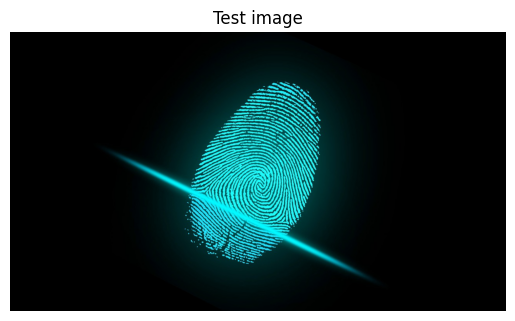

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("medicale.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Test image")
plt.axis("off")
plt.show()

In [ ]:
import cv2

img = cv2.imread("medicale.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 1)

appliquer Roberts

In [ ]:
import cv2
import numpy as np

def roberts(gray):
    kernel_x = np.array([[1, 0],
                         [0, -1]], dtype=np.float32)

    kernel_y = np.array([[0, 1],
                         [-1, 0]], dtype=np.float32)

    gx = cv2.filter2D(gray.astype(np.float32), -1, kernel_x)
    gy = cv2.filter2D(gray.astype(np.float32), -1, kernel_y)

    mag = np.sqrt(gx**2 + gy**2)
    mag = np.uint8(255 * mag / np.max(mag))
    return mag

appliquer Prewitt

In [ ]:
def prewitt(gray):
    kernel_x = np.array([[-1, 0, 1],
                         [-1, 0, 1],
                         [-1, 0, 1]], dtype=np.float32)

    kernel_y = np.array([[-1, -1, -1],
                         [ 0,  0,  0],
                         [ 1,  1,  1]], dtype=np.float32)

    gx = cv2.filter2D(gray.astype(np.float32), -1, kernel_x)
    gy = cv2.filter2D(gray.astype(np.float32), -1, kernel_y)

    mag = np.sqrt(gx**2 + gy**2)
    mag = np.uint8(255 * mag / np.max(mag))
    return mag

appliquer Sobel

In [ ]:
def sobel(gray):
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

    mag = np.sqrt(gx**2 + gy**2)
    mag = np.uint8(255 * mag / np.max(mag))
    return mag

appliquer Canny

In [ ]:
def canny(gray):
    blur = cv2.GaussianBlur(gray, (5,5), 1)
    edges = cv2.Canny(blur, 50, 150)
    return edges

calcule des imgs

In [ ]:
roberts_img = roberts(gray)
prewitt_img = prewitt(gray)
sobel_img = sobel(gray)
canny_img = canny(gray)

afficher les résultats

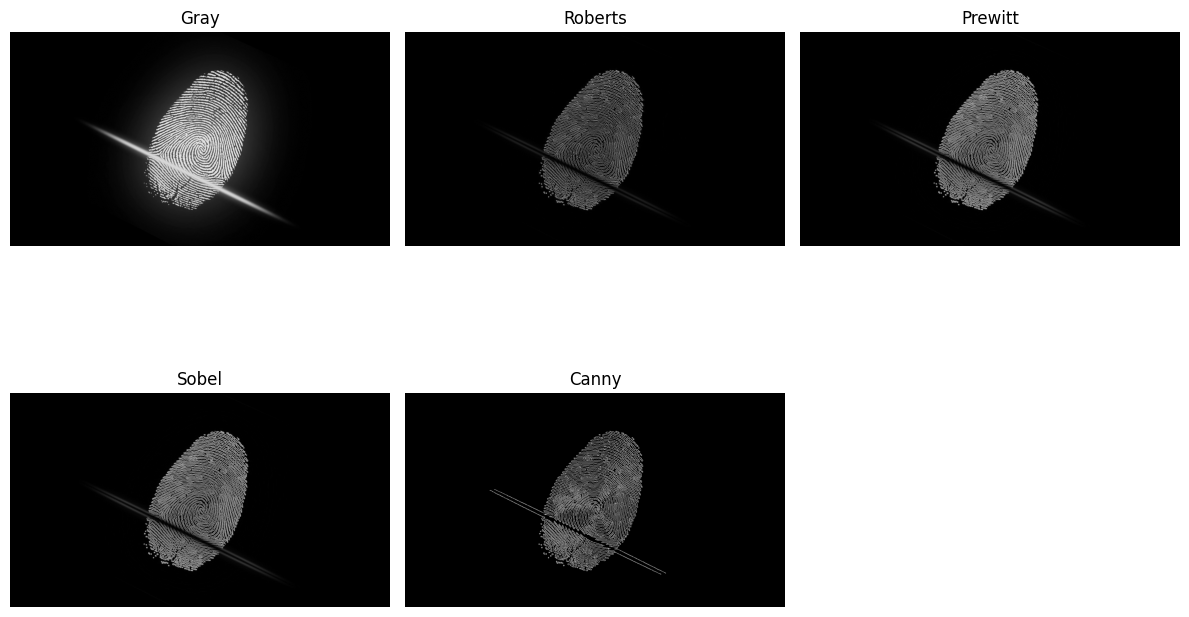

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Gray")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(roberts_img, cmap='gray')
plt.title("Roberts")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(prewitt_img, cmap='gray')
plt.title("Prewitt")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(sobel_img, cmap='gray')
plt.title("Sobel")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(canny_img, cmap='gray')
plt.title("Canny")
plt.axis("off")

plt.tight_layout()
plt.show()

Ajouter une fonction de seuillage

In [ ]:
def seuil_binaire(img, seuil):
    _, binary = cv2.threshold(img, seuil, 255, cv2.THRESH_BINARY)
    return binary

quelques seuils

In [ ]:
seuils = [50, 100, 150]

Appliquer les seuils à Roberts, Prewitt et Sobel

In [ ]:
# Seuils pour Roberts
roberts_50 = seuil_binaire(roberts_img, 50)
roberts_100 = seuil_binaire(roberts_img, 100)
roberts_150 = seuil_binaire(roberts_img, 150)

# Seuils pour Prewitt
prewitt_50 = seuil_binaire(prewitt_img, 50)
prewitt_100 = seuil_binaire(prewitt_img, 100)
prewitt_150 = seuil_binaire(prewitt_img, 150)

# Seuils pour Sobel
sobel_50 = seuil_binaire(sobel_img, 50)
sobel_100 = seuil_binaire(sobel_img, 100)
sobel_150 = seuil_binaire(sobel_img, 150)

Tester plusieurs réglages pour Canny

In [ ]:
canny_30_100 = cv2.Canny(gray, 30, 100)
canny_50_150 = cv2.Canny(gray, 50, 150)
canny_80_200 = cv2.Canny(gray, 80, 200)

Afficher les résultats seuillés

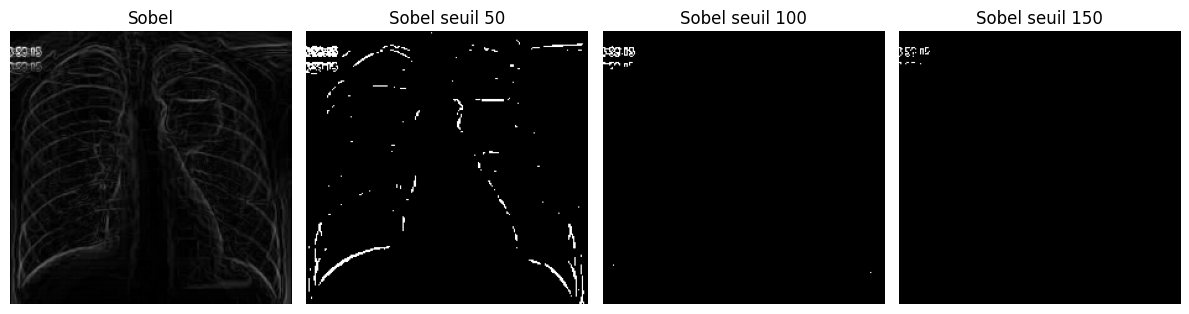

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(sobel_img, cmap="gray")
plt.title("Sobel")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(sobel_50, cmap="gray")
plt.title("Sobel seuil 50")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(sobel_100, cmap="gray")
plt.title("Sobel seuil 100")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(sobel_150, cmap="gray")
plt.title("Sobel seuil 150")
plt.axis("off")

plt.tight_layout()
plt.show()

Exemple pour Canny

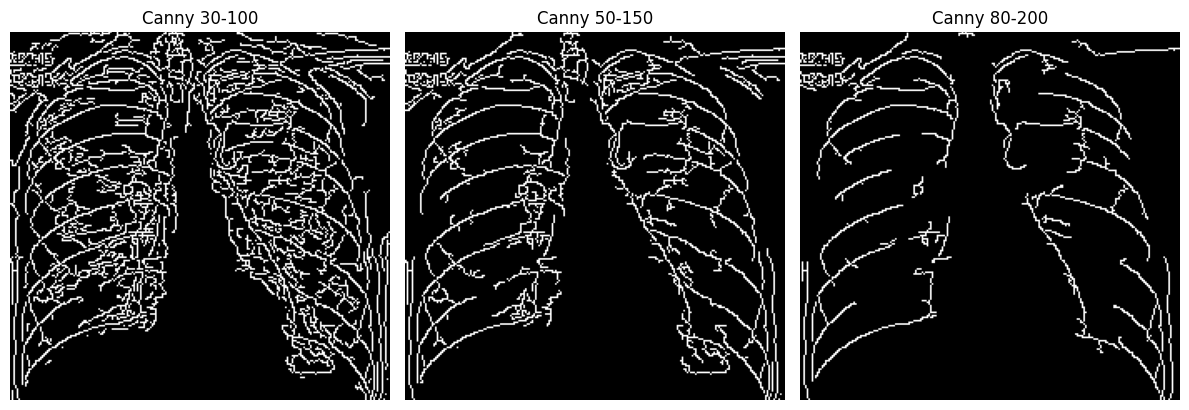

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(canny_30_100, cmap="gray")
plt.title("Canny 30-100")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(canny_50_150, cmap="gray")
plt.title("Canny 50-150")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(canny_80_200, cmap="gray")
plt.title("Canny 80-200")
plt.axis("off")

plt.tight_layout()
plt.show()